Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
weighted_update_path = Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
weighted_update_df = pd.read_csv(weighted_update_path, low_memory=False)

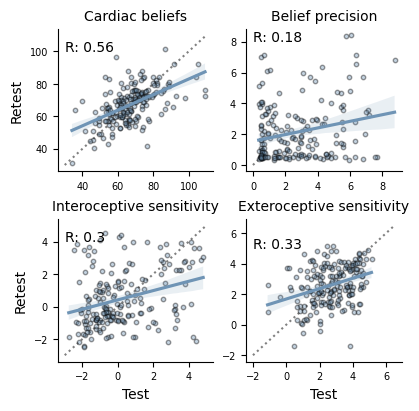

In [3]:
fig, axs = plt.subplots(figsize=(4, 4), ncols=2, nrows=2)

merged = pd.merge(
    weighted_update_df[weighted_update_df.session == 1],
    weighted_update_df[weighted_update_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

sns.regplot(
    x=merged["cardiac_belief_del1"],
    y=merged["cardiac_belief_del2"],
    scatter_kws={"s": 10, "alpha": .4, "edgecolor": "k"},
    color="#6f94b5",
    ax=axs[0, 0]
)
axs[0, 0].annotate(
    f"R: {round(pg.corr(
    x=merged["cardiac_belief_del1"].to_numpy(),
    y=merged["cardiac_belief_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (30, 100)
)



sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"],
    y=merged["logit_interoceptive_sensitivity_del2"],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": .4, "edgecolor": "k"},
    ax=axs[1, 0]
)
axs[1, 0].annotate(
    f"R: {round(pg.corr(
    x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (-3, 4)
)


sns.regplot(
    x=merged["pi_cardiac_belief_del1"],
    y=merged["pi_cardiac_belief_del2"],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": .4, "edgecolor": "k"},
    ax=axs[0, 1]
)
axs[0, 1].annotate(
    f"R: {round(pg.corr(
    x=merged["pi_cardiac_belief_del1"].to_numpy(),
    y=merged["pi_cardiac_belief_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (0.01, 8)
)


sns.regplot(
    x=merged["logit_exteroceptive_sensitivity_del1"],
    y=merged["logit_exteroceptive_sensitivity_del2"],
    color="#6f94b5",
    scatter_kws={"s": 10, "alpha": .4, "edgecolor": "k"},
    ax=axs[1, 1]
)
axs[1, 1].annotate(
    f"R: {round(pg.corr(
    x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
    method="spearman",
).r.iloc[0], 2)}",
    (-2, 5)
)

axs[0, 0].plot((30, 110), (30, 110), linestyle=":", color="gray", zorder=0)
axs[0, 0].tick_params(axis='both', labelsize=7)
axs[0, 0].set_title("Cardiac beliefs", fontsize=10)

axs[1, 0].plot((-3, 5), (-3, 5), linestyle=":", color="gray", zorder=0)
axs[1, 0].tick_params(axis='both', labelsize=7)
axs[1, 0].set_title("Interoceptive sensitivity", fontsize=10)

axs[0, 1].plot((0, .4), (0, .4), linestyle=":", color="gray", zorder=0)
axs[0, 1].tick_params(axis='both', labelsize=7)
axs[0, 1].set_title("Belief precision", fontsize=10)

axs[1, 1].plot((-2, 6.5), (-2, 6.5), linestyle=":", color="gray", zorder=0)
axs[1, 1].tick_params(axis='both', labelsize=7)
axs[1, 1].set_title("Exteroceptive sensitivity", fontsize=10)

axs[0, 0].set(xlabel=None, ylabel="Retest")
axs[1, 0].set(xlabel="Test", ylabel="Retest")
axs[0, 1].set(xlabel=None, ylabel=None)
axs[1, 1].set(xlabel="Test", ylabel=None)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_reliability.svg")